# Imports

In [1]:
import math
import os
import random
import re
from collections import Counter
from getpass import getpass
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from datasets import load_dataset
from huggingface_hub import login
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer

### Seed and set device

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### HF Auth for higher limits

In [4]:
HF_TOKEN = os.getenv("HF_TOKEN") or os.getenv("HUGGINGFACE_TOKEN")

if not HF_TOKEN:
    HF_TOKEN = getpass("Enter Hugging Face token (starts with hf_): ").strip()

if HF_TOKEN:
    login(token=HF_TOKEN, add_to_git_credential=False)
    print("Hugging Face login successful.")
else:
    print("No token provided. Public resources may still download without auth.")

Hugging Face login successful.


In [5]:
NOTEBOOK_DIR = Path(".").resolve()
DATA_DIR = NOTEBOOK_DIR / "data"
HF_CACHE_DIR = DATA_DIR / "hf_cache"

DATA_DIR.mkdir(parents=True, exist_ok=True)
HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)

flickr8k_ds = load_dataset(
    "jxie/flickr8k",
    cache_dir=str(HF_CACHE_DIR),
    token=HF_TOKEN if HF_TOKEN else None
)
print(flickr8k_ds)

data/train-00000-of-00002-2f8f6bfa852eac(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/train-00001-of-00002-2173151d8cd6c7(…):   0%|          | 0.00/414M [00:00<?, ?B/s]

data/validation-00000-of-00001-7025a2b59(…):   0%|          | 0.00/138M [00:00<?, ?B/s]

data/test-00000-of-00001-42a2661d12c73e4(…):   0%|          | 0.00/137M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 6000
    })
    validation: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
        num_rows: 1000
    })
})


In [6]:
def _extract_caption_list(example):
    caption_keys = [k for k in example.keys() if k.startswith("caption_")]
    caption_keys = sorted(
        caption_keys,
        key=lambda k: int(k.split("_")[1]) if k.split("_")[1].isdigit() else k
    )

    captions = []
    for key in caption_keys:
        text = example.get(key, "")
        if isinstance(text, str) and text.strip():
            captions.append(text.strip())

    # Fallback for alternate dataset schemas.
    if not captions and "captions" in example and isinstance(example["captions"], list):
        captions = [str(c).strip() for c in example["captions"] if str(c).strip()]

    if not captions and "caption" in example:
        cap = example["caption"]
        if isinstance(cap, list):
            captions = [str(c).strip() for c in cap if str(c).strip()]
        elif isinstance(cap, str) and cap.strip():
            captions = [cap.strip()]

    return captions[:5]


def normalize_split(hf_split, split_name):
    records = []
    for idx, ex in enumerate(hf_split):
        image = ex.get("image", None)
        image_id = (
            ex.get("image_id")
            or ex.get("img_id")
            or ex.get("id")
            or ex.get("filename")
            or ex.get("file_name")
        )

        if image_id is None:
            if hasattr(image, "filename") and image.filename:
                image_id = Path(image.filename).name
            else:
                image_id = f"{split_name}_{idx}"

        captions = _extract_caption_list(ex)

        records.append({
            "image_id": image_id,
            "image": image,
            "captions": captions
        })

    return records

### Assertion of the loaded dataset

In [7]:
train_records = normalize_split(flickr8k_ds["train"], "train")
val_records = normalize_split(flickr8k_ds["validation"], "validation")
test_records = normalize_split(flickr8k_ds["test"], "test")

print(f"Train samples: {len(train_records)}")
print(f"Validation samples: {len(val_records)}")
print(f"Test samples: {len(test_records)}")

assert len(train_records) == 6000, "Expected 6000 train samples"
assert len(val_records) == 1000, "Expected 1000 validation samples"
assert len(test_records) == 1000, "Expected 1000 test samples"

assert all(len(r["captions"]) == 5 for r in train_records), "Train split must contain 5 captions per image"
assert all(len(r["captions"]) == 5 for r in val_records), "Validation split must contain 5 captions per image"
assert all(len(r["captions"]) == 5 for r in test_records), "Test split must contain 5 captions per image"

train_ids = {str(r["image_id"]) for r in train_records}
val_ids = {str(r["image_id"]) for r in val_records}
test_ids = {str(r["image_id"]) for r in test_records}

assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)

print("Split integrity check passed: all partitions contain distinct images.")
print("Caption integrity check passed: each image has exactly 5 captions.")

Train samples: 6000
Validation samples: 1000
Test samples: 1000
Split integrity check passed: all partitions contain distinct images.
Caption integrity check passed: each image has exactly 5 captions.


### Dataset sample

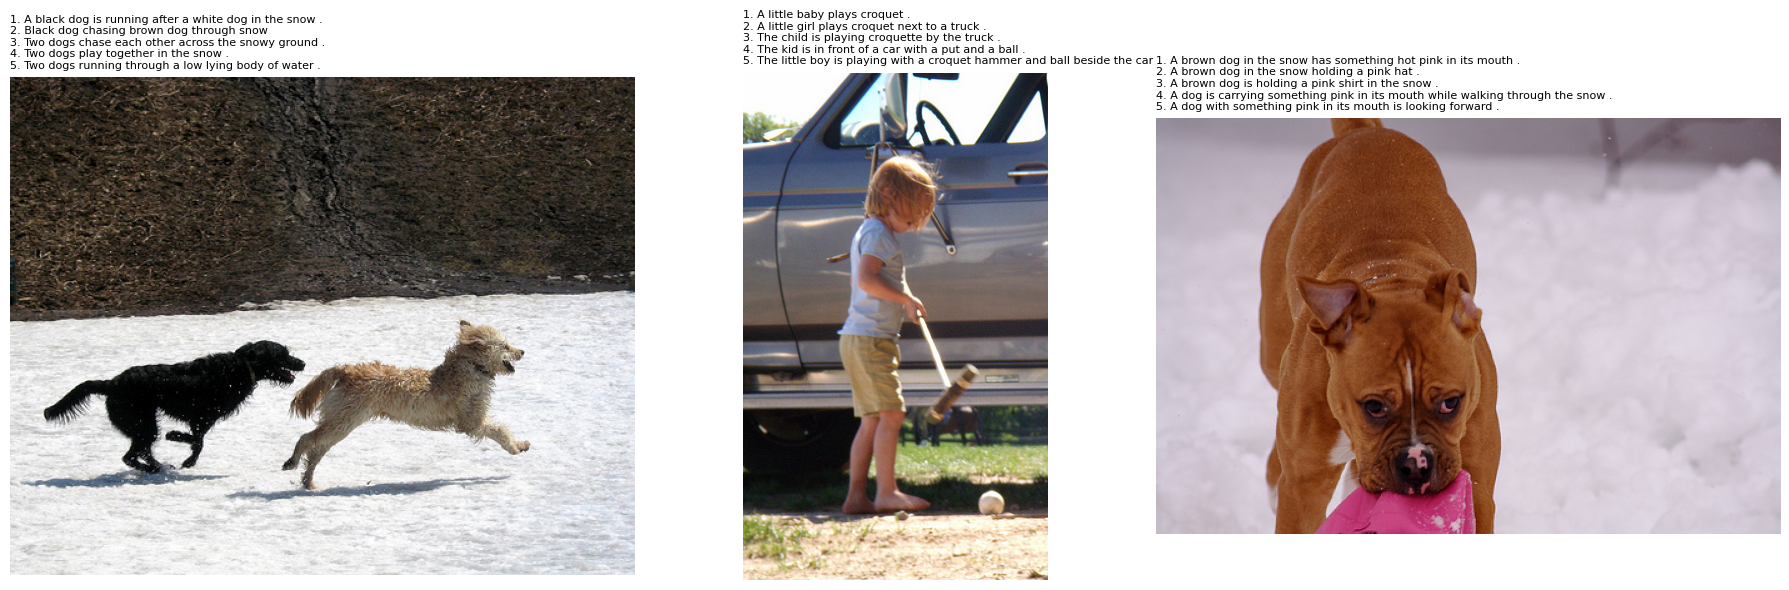

In [8]:
def show_dataset_samples(records, n=3):
    n = min(n, len(records))
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))
    if n == 1:
        axes = [axes]

    for i, ax in enumerate(axes):
        rec = records[i]
        ax.imshow(rec["image"])
        ax.axis("off")
        caps = rec["captions"][:5]
        title_text = "\n".join([f"{j+1}. {c}" for j, c in enumerate(caps)])
        ax.set_title(title_text, fontsize=8, loc="left")

    plt.tight_layout()
    plt.show()


show_dataset_samples(train_records, n=3)

In [9]:
SPECIAL_TOKENS = ["<pad>", "<bos>", "<eos>", "<unk>"]

def tokenize_caption(text):
    return re.findall(r"[a-z0-9]+(?:'[a-z0-9]+)?|[.,!?;:]", text.lower())


def build_vocab(records, min_freq=2):
    counter = Counter()
    for rec in records:
        for cap in rec["captions"]:
            counter.update(tokenize_caption(cap))

    itos = SPECIAL_TOKENS.copy()
    for tok, freq in counter.items():
        if freq >= min_freq:
            itos.append(tok)

    stoi = {tok: idx for idx, tok in enumerate(itos)}
    return stoi, itos, counter


stoi, itos, token_counter = build_vocab(train_records, min_freq=2)

PAD_IDX = stoi["<pad>"]
BOS_IDX = stoi["<bos>"]
EOS_IDX = stoi["<eos>"]
UNK_IDX = stoi["<unk>"]
VOCAB_SIZE = len(itos)
MAX_CAPTION_LEN = 40

print(f"Vocabulary size: {VOCAB_SIZE}")


def encode_caption(caption):
    tokens = tokenize_caption(caption)[: MAX_CAPTION_LEN - 2]
    ids = [BOS_IDX] + [stoi.get(tok, UNK_IDX) for tok in tokens] + [EOS_IDX]
    return torch.tensor(ids, dtype=torch.long)


image_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor()
])


class Flickr8kCaptionDataset(Dataset):
    def __init__(self, records, transform=None):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        image = rec["image"]

        if not isinstance(image, Image.Image):
            image = Image.fromarray(np.array(image))

        image = image.convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        return {
            "image": image,
            "captions": rec["captions"],
            "image_id": rec["image_id"]
        }


def collate_train(batch):
    images = torch.stack([b["image"] for b in batch], dim=0)
    caption_tensors = []

    for b in batch:
        if b["captions"]:
            selected = random.choice(b["captions"])
        else:
            selected = ""
        caption_tensors.append(encode_caption(selected))

    captions = pad_sequence(caption_tensors, batch_first=True, padding_value=PAD_IDX)
    return images, captions


def collate_eval(batch):
    images = torch.stack([b["image"] for b in batch], dim=0)

    caption_tensors = []
    refs = []
    for b in batch:
        refs.append(b["captions"])
        selected = b["captions"][0] if b["captions"] else ""
        caption_tensors.append(encode_caption(selected))

    captions = pad_sequence(caption_tensors, batch_first=True, padding_value=PAD_IDX)
    return images, captions, refs


def collate_bleu(batch):
    images = torch.stack([b["image"] for b in batch], dim=0)
    refs = [b["captions"] for b in batch]
    return images, refs


Vocabulary size: 4454


In [10]:
BATCH_SIZE = 16

train_dataset = Flickr8kCaptionDataset(train_records, transform=image_transform)
val_dataset = Flickr8kCaptionDataset(val_records, transform=image_transform)
test_dataset = Flickr8kCaptionDataset(test_records, transform=image_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_train)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_eval)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_eval)
test_bleu_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_bleu)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test BLEU batches: {len(test_bleu_loader)}")

Train batches: 375
Validation batches: 63
Test BLEU batches: 63


# Custom Transformer

In [11]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-(math.log(10000.0) / d_model)))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, : x.size(1), :]


class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=256):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class CustomTransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.act = nn.ReLU()

    def forward(self, src):
        attn_out, _ = self.self_attn(src, src, src, need_weights=False)
        src = self.norm1(src + self.dropout(attn_out))

        ff = self.linear2(self.dropout(self.act(self.linear1(src))))
        src = self.norm2(src + self.dropout(ff))
        return src


class CustomTransformerDecoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward, dropout):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)

        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)
        self.act = nn.ReLU()

    def forward(self, tgt, memory, tgt_mask=None, tgt_key_padding_mask=None):
        self_attn_out, _ = self.self_attn(
            tgt, tgt, tgt,
            attn_mask=tgt_mask,
            key_padding_mask=tgt_key_padding_mask,
            need_weights=False
        )
        tgt = self.norm1(tgt + self.dropout(self_attn_out))

        cross_attn_out, _ = self.cross_attn(tgt, memory, memory, need_weights=False)
        tgt = self.norm2(tgt + self.dropout(cross_attn_out))

        ff = self.linear2(self.dropout(self.act(self.linear1(tgt))))
        tgt = self.norm3(tgt + self.dropout(ff))
        return tgt


class CustomImageCaptioningTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=256,
        nhead=8,
        num_encoder_layers=4,
        num_decoder_layers=4,
        dim_feedforward=512,
        dropout=0.1,
        img_size=224,
        patch_size=16
    ):
        super().__init__()
        self.d_model = d_model

        self.patch_embed = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            in_channels=3,
            embed_dim=d_model
        )

        self.src_pos = SinusoidalPositionalEncoding(d_model, max_len=(img_size // patch_size) ** 2 + 1)
        self.tgt_embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.tgt_pos = SinusoidalPositionalEncoding(d_model, max_len=MAX_CAPTION_LEN + 5)

        self.encoder_layers = nn.ModuleList([
            CustomTransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_encoder_layers)
        ])

        self.decoder_layers = nn.ModuleList([
            CustomTransformerDecoderLayer(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_decoder_layers)
        ])

        self.dropout = nn.Dropout(dropout)
        self.out_proj = nn.Linear(d_model, vocab_size)

    def _generate_causal_mask(self, tgt_len, device):
        return torch.triu(torch.ones((tgt_len, tgt_len), dtype=torch.bool, device=device), diagonal=1)

    def forward(self, images, tgt_tokens):
        src = self.patch_embed(images)
        src = self.dropout(self.src_pos(src))

        for layer in self.encoder_layers:
            src = layer(src)

        tgt = self.tgt_embed(tgt_tokens) * math.sqrt(self.d_model)
        tgt = self.dropout(self.tgt_pos(tgt))

        tgt_mask = self._generate_causal_mask(tgt.size(1), tgt.device)
        tgt_key_padding_mask = tgt_tokens.eq(PAD_IDX)

        for layer in self.decoder_layers:
            tgt = layer(tgt, src, tgt_mask=tgt_mask, tgt_key_padding_mask=tgt_key_padding_mask)

        logits = self.out_proj(tgt)
        return logits


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [12]:
IMG_SIZE = 224
PATCH_SIZE = 16
D_MODEL = 256
NHEAD = 8
NUM_ENCODER_LAYERS = 4
NUM_DECODER_LAYERS = 4
FF_DIM = 512
DROPOUT = 0.1
LR = 1e-4
NUM_EPOCHS = 10

In [13]:
custom_model = CustomImageCaptioningTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_encoder_layers=NUM_ENCODER_LAYERS,
    num_decoder_layers=NUM_DECODER_LAYERS,
    dim_feedforward=FF_DIM,
    dropout=DROPOUT,
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE
).to(device)

print(custom_model)
print(f"Trainable parameters (custom): {count_trainable_params(custom_model):,}")

CustomImageCaptioningTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 256, kernel_size=(16, 16), stride=(16, 16))
  )
  (src_pos): SinusoidalPositionalEncoding()
  (tgt_embed): Embedding(4454, 256, padding_idx=0)
  (tgt_pos): SinusoidalPositionalEncoding()
  (encoder_layers): ModuleList(
    (0-3): 4 x CustomTransformerEncoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (linear1): Linear(in_features=256, out_features=512, bias=True)
      (linear2): Linear(in_features=512, out_features=256, bias=True)
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (act): ReLU()
    )
  )
  (decoder_layers): ModuleList(
    (0-3): 4 x CustomTransformerDecoderLayer(
      (self_attn): MultiheadAttention(
        (out_proj): NonDynami

## Training

In [14]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)


def autoregressive_caption_loss(logits, target_tokens):
    return criterion(logits.reshape(-1, logits.size(-1)), target_tokens.reshape(-1))


def train_one_epoch(model, loader, optimizer, epoch_idx, num_epochs):
    model.train()
    running_loss = 0.0

    batch_bar = tqdm(loader, leave=False, desc=f"Epoch {epoch_idx + 1}/{num_epochs} [Train]")
    for images, captions in batch_bar:
        images = images.to(device)
        captions = captions.to(device)

        decoder_in = captions[:, :-1]
        decoder_target = captions[:, 1:]

        optimizer.zero_grad()
        logits = model(images, decoder_in)
        loss = autoregressive_caption_loss(logits, decoder_target)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        batch_bar.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / max(1, len(loader))


@torch.no_grad()
def validate_one_epoch(model, loader, epoch_idx, num_epochs):
    model.eval()
    running_loss = 0.0

    batch_bar = tqdm(loader, leave=False, desc=f"Epoch {epoch_idx + 1}/{num_epochs} [Val]")
    for images, captions, _ in batch_bar:
        images = images.to(device)
        captions = captions.to(device)

        decoder_in = captions[:, :-1]
        decoder_target = captions[:, 1:]

        logits = model(images, decoder_in)
        loss = autoregressive_caption_loss(logits, decoder_target)

        running_loss += loss.item()
        batch_bar.set_postfix(loss=f"{loss.item():.4f}")

    return running_loss / max(1, len(loader))


def fit_model(model, train_loader, val_loader, optimizer, num_epochs):
    history = {"train_loss": [], "val_loss": []}

    epoch_bar = tqdm(range(num_epochs), desc="Epoch Progress")
    for epoch_idx in epoch_bar:
        train_loss = train_one_epoch(model, train_loader, optimizer, epoch_idx, num_epochs)
        val_loss = validate_one_epoch(model, val_loader, epoch_idx, num_epochs)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        epoch_bar.set_description(f"Epoch Progress ({epoch_idx + 1}/{num_epochs})")
        epoch_bar.set_postfix(train_loss=f"{train_loss:.4f}", val_loss=f"{val_loss:.4f}")

    return history


def plot_loss_curves(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], marker="o", label="Train Loss")
    plt.plot(history["val_loss"], marker="s", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Train loop

In [15]:
custom_optimizer = torch.optim.Adam(custom_model.parameters(), lr=LR)
custom_history = fit_model(custom_model, train_loader, val_loader, custom_optimizer, NUM_EPOCHS)

Epoch Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10 [Train]:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 2/10 [Train]:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 2/10 [Val]:   0%|          | 0/63 [00:00<?, ?it/s]

...

Epoch 8/10 [Val]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 9/10 [Train]:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 9/10 [Val]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 10/10 [Train]:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/63 [00:00<?, ?it/s]

### Plot train curves

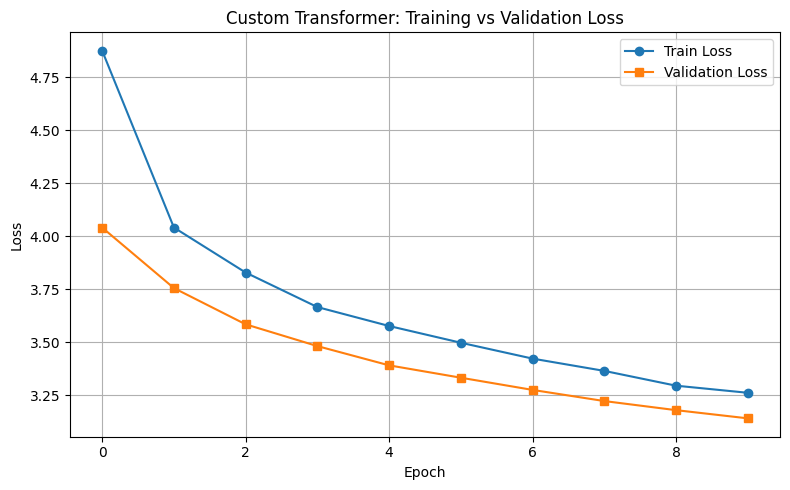

In [16]:
plot_loss_curves(custom_history, "Custom Transformer: Training vs Validation Loss")

## Evaluation

In [17]:
def ids_to_tokens(token_ids):
    out = []
    for idx in token_ids:
        if idx == EOS_IDX:
            break
        if idx in (PAD_IDX, BOS_IDX):
            continue
        out.append(itos[idx] if idx < len(itos) else "<unk>")
    return out


@torch.no_grad()
def greedy_decode_caption(model, image_tensor, max_len=MAX_CAPTION_LEN):
    model.eval()

    generated = [BOS_IDX]
    image_batch = image_tensor.unsqueeze(0).to(device)

    for _ in range(max_len - 1):
        tgt = torch.tensor(generated, dtype=torch.long, device=device).unsqueeze(0)
        logits = model(image_batch, tgt)
        next_token = int(logits[0, -1].argmax().item())
        generated.append(next_token)

        if next_token == EOS_IDX:
            break

    return ids_to_tokens(generated[1:])


smooth_fn = SmoothingFunction().method1


def sample_average_bleu(candidate_tokens, references):
    cand = candidate_tokens if candidate_tokens else ["<empty>"]

    scores = []
    for ref in references[:5]:
        ref_tokens = tokenize_caption(ref)
        if not ref_tokens:
            continue
        score = sentence_bleu([ref_tokens], cand, smoothing_function=smooth_fn)
        scores.append(score)

    return float(np.mean(scores)) if scores else 0.0


@torch.no_grad()
def evaluate_model_bleu(model, bleu_loader):
    model.eval()
    all_scores = []

    batch_bar = tqdm(bleu_loader, leave=False, desc="BLEU Evaluation")
    for images, refs_batch in batch_bar:
        for image_tensor, refs in zip(images, refs_batch):
            pred_tokens = greedy_decode_caption(model, image_tensor)
            sample_bleu = sample_average_bleu(pred_tokens, refs)
            all_scores.append(sample_bleu)

        if all_scores:
            batch_bar.set_postfix(avg_bleu=f"{np.mean(all_scores):.4f}")

    return float(np.mean(all_scores))

In [18]:
custom_test_bleu = evaluate_model_bleu(custom_model, test_bleu_loader)
print(f"Custom transformer average BLEU on test set: {custom_test_bleu:.4f}")

BLEU Evaluation:   0%|          | 0/63 [00:00<?, ?it/s]

Custom transformer average BLEU on test set: 0.0340


# Native PyTorch Transformer Encoder/Decoder

In [19]:
class NativeImageCaptioningTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model=256,
        nhead=8,
        num_encoder_layers=4,
        num_decoder_layers=4,
        dim_feedforward=512,
        dropout=0.1,
        img_size=224,
        patch_size=16
    ):
        super().__init__()
        self.d_model = d_model

        self.patch_embed = PatchEmbedding(
            img_size=img_size,
            patch_size=patch_size,
            in_channels=3,
            embed_dim=d_model
        )

        self.src_pos = SinusoidalPositionalEncoding(d_model, max_len=(img_size // patch_size) ** 2 + 1)
        self.tgt_embed = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.tgt_pos = SinusoidalPositionalEncoding(d_model, max_len=MAX_CAPTION_LEN + 5)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_decoder_layers)

        self.dropout = nn.Dropout(dropout)
        self.out_proj = nn.Linear(d_model, vocab_size)

    def _generate_causal_mask(self, tgt_len, device):
        return torch.triu(torch.ones((tgt_len, tgt_len), dtype=torch.bool, device=device), diagonal=1)

    def forward(self, images, tgt_tokens):
        src = self.patch_embed(images)
        src = self.dropout(self.src_pos(src))
        memory = self.encoder(src)

        tgt = self.tgt_embed(tgt_tokens) * math.sqrt(self.d_model)
        tgt = self.dropout(self.tgt_pos(tgt))

        tgt_mask = self._generate_causal_mask(tgt.size(1), tgt.device)
        tgt_key_padding_mask = tgt_tokens.eq(PAD_IDX)

        decoded = self.decoder(
            tgt=tgt,
            memory=memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask
        )

        logits = self.out_proj(decoded)
        return logits

In [20]:
native_model = NativeImageCaptioningTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_encoder_layers=NUM_ENCODER_LAYERS,
    num_decoder_layers=NUM_DECODER_LAYERS,
    dim_feedforward=FF_DIM,
    dropout=DROPOUT,
    img_size=IMG_SIZE,
    patch_size=PATCH_SIZE
).to(device)

print(native_model)
print(f"Trainable parameters (native): {count_trainable_params(native_model):,}")

NativeImageCaptioningTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(3, 256, kernel_size=(16, 16), stride=(16, 16))
  )
  (src_pos): SinusoidalPositionalEncoding()
  (tgt_embed): Embedding(4454, 256, padding_idx=0)
  (tgt_pos): SinusoidalPositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=256, bias=True)
        (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (decoder): Transf

### Train loop pytorch

In [21]:
native_optimizer = torch.optim.Adam(native_model.parameters(), lr=LR)
native_history = fit_model(native_model, train_loader, val_loader, native_optimizer, NUM_EPOCHS)

Epoch Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10 [Train]:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 1/10 [Val]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 2/10 [Train]:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 2/10 [Val]:   0%|          | 0/63 [00:00<?, ?it/s]

...

Epoch 8/10 [Val]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 9/10 [Train]:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 9/10 [Val]:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 10/10 [Train]:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 10/10 [Val]:   0%|          | 0/63 [00:00<?, ?it/s]

### Plot train data pytorch

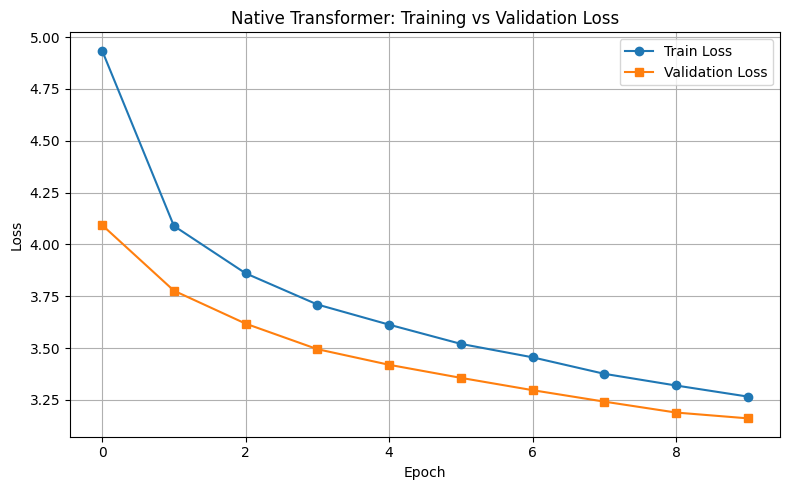

In [22]:
plot_loss_curves(native_history, "Native Transformer: Training vs Validation Loss")

## Evaluation Pytorch

In [23]:
native_test_bleu = evaluate_model_bleu(native_model, test_bleu_loader)
print(f"Native transformer average BLEU on test set: {native_test_bleu:.4f}")

BLEU Evaluation:   0%|          | 0/63 [00:00<?, ?it/s]

Native transformer average BLEU on test set: 0.0336


# Pre-trained ViT-GPT2 Baseline

In [24]:
vit_gpt2_name = "nlpconnect/vit-gpt2-image-captioning"

vit_gpt2_processor = ViTImageProcessor.from_pretrained(
    vit_gpt2_name,
    cache_dir=str(HF_CACHE_DIR),
    token=HF_TOKEN if HF_TOKEN else None
)
vit_gpt2_tokenizer = AutoTokenizer.from_pretrained(
    vit_gpt2_name,
    cache_dir=str(HF_CACHE_DIR),
    token=HF_TOKEN if HF_TOKEN else None
)
vit_gpt2_model = VisionEncoderDecoderModel.from_pretrained(
    vit_gpt2_name,
    cache_dir=str(HF_CACHE_DIR),
    token=HF_TOKEN if HF_TOKEN else None
).to(device)
vit_gpt2_model.eval()


@torch.no_grad()
def evaluate_vit_gpt2_bleu(records, batch_size=16, max_length=32, num_beams=4):
    all_scores = []

    for start in tqdm(range(0, len(records), batch_size), desc="ViT-GPT2 Evaluation"):
        batch = records[start : start + batch_size]

        images = []
        refs_batch = []
        for rec in batch:
            img = rec["image"]
            if not isinstance(img, Image.Image):
                img = Image.fromarray(np.array(img))
            images.append(img.convert("RGB"))
            refs_batch.append(rec["captions"])

        pixel_values = vit_gpt2_processor(images=images, return_tensors="pt").pixel_values.to(device)
        generated_ids = vit_gpt2_model.generate(
            pixel_values,
            max_length=max_length,
            num_beams=num_beams
        )

        generated_texts = vit_gpt2_tokenizer.batch_decode(generated_ids, skip_special_tokens=True)

        for pred_text, refs in zip(generated_texts, refs_batch):
            pred_tokens = tokenize_caption(pred_text)
            sample_bleu = sample_average_bleu(pred_tokens, refs)
            all_scores.append(sample_bleu)

    return float(np.mean(all_scores))

preprocessor_config.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/241 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.crossattention.bias        | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/982M [00:00<?, ?B/s]

## Evaluation GPT2

In [25]:
vit_gpt2_test_bleu = evaluate_vit_gpt2_bleu(test_records, batch_size=BATCH_SIZE)
print(f"ViT-GPT2 average BLEU on test set: {vit_gpt2_test_bleu:.4f}")

ViT-GPT2 Evaluation:   0%|          | 0/63 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


ViT-GPT2 average BLEU on test set: 0.0508


In [27]:
results = {
    "Custom Transformer": custom_test_bleu,
    "Native Transformer": native_test_bleu,
    "Pretrained ViT-GPT2": vit_gpt2_test_bleu
}

print("Average BLEU Scores on Test Set")
for name, score in results.items():
    print(f"{name:25s}: {score:.4f}")

best_model_name = max(results, key=results.get)
print()
print(f"Best BLEU in this run: {best_model_name}")

Average BLEU Scores on Test Set
Custom Transformer       : 0.0340
Native Transformer       : 0.0336
Pretrained ViT-GPT2      : 0.0508

Best BLEU in this run: Pretrained ViT-GPT2
